In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# CUSTOMER CHURN ANALYSIS
# Stage 1: Data Audit
# ============================================================

# Load data
DATA_PATH = "../Data/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# 1. Basic information
# ------------------------------------------------------------

print("=" * 70)
print("CUSTOMER CHURN DATA AUDIT")
print("=" * 70)

print("\n[1] DATASET SHAPE")
print("-" * 70)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

# ------------------------------------------------------------
# 2. Columns
# ------------------------------------------------------------

print("\n[2] COLUMNS")
print("-" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

# ------------------------------------------------------------
# 3. Data types
# ------------------------------------------------------------

print("\n[3] DATA TYPES")
print("-" * 70)
print(df.dtypes)

# ------------------------------------------------------------
# 4. Missing values
# ------------------------------------------------------------

print("\n[4] MISSING VALUES")
print("-" * 70)

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["missing_count"] > 0
].sort_values("missing_count", ascending=False)

if missing_table.empty:
    print("No standard missing values detected.")
else:
    print(missing_table)

# ------------------------------------------------------------
# 5. Duplicate rows
# ------------------------------------------------------------

print("\n[5] DUPLICATE ROWS")
print("-" * 70)

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

# ------------------------------------------------------------
# 6. Unique values
# ------------------------------------------------------------

print("\n[6] UNIQUE VALUES")
print("-" * 70)

unique_table = pd.DataFrame({
    "column": df.columns,
    "unique_values": [
        df[column].nunique(dropna=False)
        for column in df.columns
    ]
})

print(unique_table.to_string(index=False))

# ------------------------------------------------------------
# 7. Churn distribution
# ------------------------------------------------------------

print("\n[7] CHURN DISTRIBUTION")
print("-" * 70)

churn_counts = df["Churn"].value_counts()

churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_table = pd.DataFrame({
    "customers": churn_counts,
    "percentage": churn_percentages
})

print(churn_table)

# ------------------------------------------------------------
# 8. TotalCharges check
# ------------------------------------------------------------

print("\n[8] TOTALCHARGES DATA QUALITY CHECK")
print("-" * 70)

print(f"Current data type: {df['TotalCharges'].dtype}")

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna().sum()

print(
    f"Values that cannot be converted to numeric: "
    f"{invalid_total_charges:,}"
)

if invalid_total_charges > 0:
    print("\nAffected rows:")
    print(
        df.loc[
            total_charges_numeric.isna(),
            ["customerID", "tenure", "TotalCharges", "Churn"]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 9. Numerical summary
# ------------------------------------------------------------

print("\n[9] NUMERICAL SUMMARY")
print("-" * 70)

print(df.describe().T)

# ------------------------------------------------------------
# 10. Customer ID check
# ------------------------------------------------------------

print("\n[10] CUSTOMER ID CHECK")
print("-" * 70)

unique_customer_ids = df["customerID"].nunique()

print(f"Total rows:          {len(df):,}")
print(f"Unique customer IDs: {unique_customer_ids:,}")

if unique_customer_ids == len(df):
    print("Every row has a unique customer ID.")
else:
    print("WARNING: Duplicate customer IDs detected.")

# ------------------------------------------------------------
# 11. Sample data
# ------------------------------------------------------------

print("\n[11] FIRST 5 RECORDS")
print("-" * 70)

print(df.head().to_string(index=False))

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

print(f"Rows:                 {len(df):,}")
print(f"Columns:              {len(df.columns):,}")
print(f"Duplicate rows:       {duplicate_count:,}")
print(f"Missing-value cells:  {df.isnull().sum().sum():,}")
print(f"Unique customers:     {unique_customer_ids:,}")
print(f"Invalid TotalCharges: {invalid_total_charges:,}")

print("=" * 70)

CUSTOMER CHURN DATA AUDIT

[1] DATASET SHAPE
----------------------------------------------------------------------
Rows:    7,043
Columns: 21

[2] COLUMNS
----------------------------------------------------------------------
 1. customerID
 2. gender
 3. SeniorCitizen
 4. Partner
 5. Dependents
 6. tenure
 7. PhoneService
 8. MultipleLines
 9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn

[3] DATA TYPES
----------------------------------------------------------------------
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSu

In [4]:
# ============================================================
# STAGE 2: DATA CLEANING
# ============================================================

print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

# Create a copy so the original dataframe remains available
clean_df = df.copy()

# ------------------------------------------------------------
# 1. Clean TotalCharges
# ------------------------------------------------------------

print("\n[1] CLEANING TOTALCHARGES")
print("-" * 70)

# Convert TotalCharges to numeric.
# Blank strings become NaN.
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

missing_total_charges = clean_df["TotalCharges"].isna().sum()

print(f"Missing TotalCharges after conversion: {missing_total_charges}")

# Customers with tenure = 0 and blank TotalCharges
# represent customers with no accumulated charges yet.
zero_tenure_missing = (
    clean_df["TotalCharges"].isna()
    & (clean_df["tenure"] == 0)
)

print(
    f"Missing TotalCharges with zero tenure: "
    f"{zero_tenure_missing.sum()}"
)

# Replace those values with 0
clean_df.loc[zero_tenure_missing, "TotalCharges"] = 0

# ------------------------------------------------------------
# 2. Convert Churn to binary
# ------------------------------------------------------------

print("\n[2] ENCODING CHURN")
print("-" * 70)

clean_df["Churn_binary"] = (
    clean_df["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

print(
    clean_df[["Churn", "Churn_binary"]]
    .drop_duplicates()
    .sort_values("Churn_binary")
    .to_string(index=False)
)

# ------------------------------------------------------------
# 3. Check for unexpected Churn values
# ------------------------------------------------------------

unexpected_churn = clean_df["Churn_binary"].isna().sum()

print(
    f"\nUnexpected/unmapped Churn values: "
    f"{unexpected_churn}"
)

# ------------------------------------------------------------
# 4. Check TotalCharges after cleaning
# ------------------------------------------------------------

remaining_total_charges_missing = (
    clean_df["TotalCharges"].isna().sum()
)

print(
    f"Remaining missing TotalCharges: "
    f"{remaining_total_charges_missing}"
)

# ------------------------------------------------------------
# 5. Check data types
# ------------------------------------------------------------

print("\n[3] UPDATED DATA TYPES")
print("-" * 70)

print(clean_df.dtypes)

# ------------------------------------------------------------
# 6. Check customer count
# ------------------------------------------------------------

print("\n[4] CUSTOMER COUNT CHECK")
print("-" * 70)

print(f"Original rows: {len(df):,}")
print(f"Cleaned rows:  {len(clean_df):,}")

# ------------------------------------------------------------
# 7. Check duplicates again
# ------------------------------------------------------------

print("\n[5] DUPLICATE CHECK")
print("-" * 70)

print(
    f"Duplicate rows after cleaning: "
    f"{clean_df.duplicated().sum():,}"
)

# ------------------------------------------------------------
# 8. Final cleaning summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEANING COMPLETE")
print("=" * 70)

print(f"Customers retained:       {len(clean_df):,}")
print(f"Missing TotalCharges:     {clean_df['TotalCharges'].isna().sum():,}")
print(f"Duplicate rows:           {clean_df.duplicated().sum():,}")
print(f"Missing Churn_binary:     {clean_df['Churn_binary'].isna().sum():,}")

print("=" * 70)

DATA CLEANING

[1] CLEANING TOTALCHARGES
----------------------------------------------------------------------
Missing TotalCharges after conversion: 11
Missing TotalCharges with zero tenure: 11

[2] ENCODING CHURN
----------------------------------------------------------------------
Churn  Churn_binary
   No             0
  Yes             1

Unexpected/unmapped Churn values: 0
Remaining missing TotalCharges: 0

[3] UPDATED DATA TYPES
----------------------------------------------------------------------
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMeth

EXPLORATORY DATA ANALYSIS
PART 1: OVERALL CUSTOMER CHURN PROFILE

[1] OVERALL CUSTOMER METRICS
----------------------------------------------------------------------
Total customers:     7,043
Churned customers:   1,869
Retained customers:  5,174
Churn rate:           26.54%
Retention rate:       73.46%

[2] CHURN SUMMARY
----------------------------------------------------------------------
       customers  avg_tenure  avg_monthly_charges  avg_total_charges  \
Churn                                                                  
No          5174       37.57                61.27            2549.91   
Yes         1869       17.98                74.44            1531.80   

       percentage  
Churn              
No          73.46  
Yes         26.54  


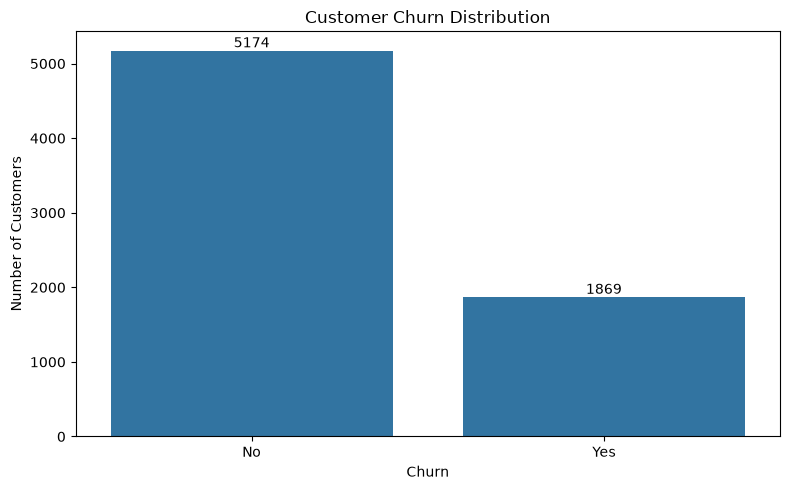

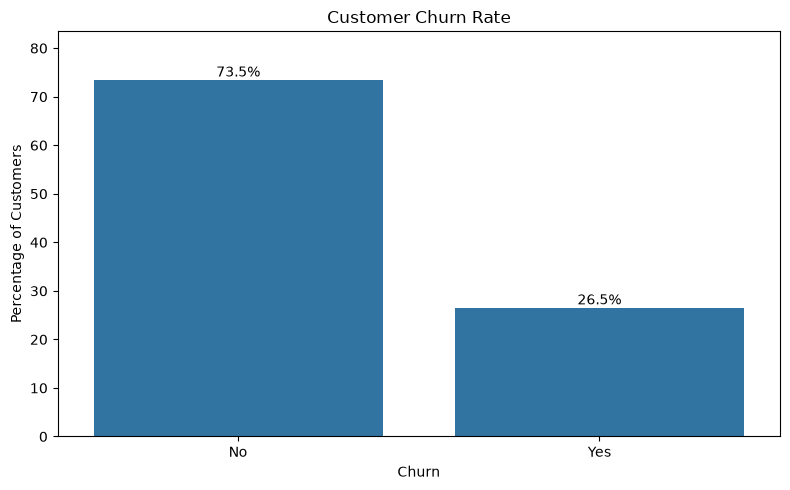


[3] CHURNED VS RETAINED CUSTOMERS
----------------------------------------------------------------------
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80

[4] INITIAL OBSERVATIONS
----------------------------------------------------------------------
• Overall churn rate: 26.54%
• 1,869 customers have churned.
• 5,174 customers have been retained.
• Average tenure differs between churned and retained customers.
• Monthly and total charges will be investigated as potential churn-related factors.

EDA PART 1 COMPLETE


In [7]:
# ============================================================
# STAGE 3: EXPLORATORY DATA ANALYSIS
# Part 1: Overall Customer Churn Profile
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("PART 1: OVERALL CUSTOMER CHURN PROFILE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Overall customer metrics
# ------------------------------------------------------------

total_customers = len(clean_df)

churned_customers = (
    clean_df["Churn_binary"] == 1
).sum()

retained_customers = (
    clean_df["Churn_binary"] == 0
).sum()

churn_rate = (
    churned_customers / total_customers
) * 100

retention_rate = (
    retained_customers / total_customers
) * 100


print("\n[1] OVERALL CUSTOMER METRICS")
print("-" * 70)

print(f"Total customers:     {total_customers:,}")
print(f"Churned customers:   {churned_customers:,}")
print(f"Retained customers:  {retained_customers:,}")
print(f"Churn rate:           {churn_rate:.2f}%")
print(f"Retention rate:       {retention_rate:.2f}%")


# ------------------------------------------------------------
# 2. Churn summary table
# ------------------------------------------------------------

print("\n[2] CHURN SUMMARY")
print("-" * 70)

churn_summary = (
    clean_df
    .groupby("Churn")
    .agg(
        customers=("customerID", "count"),
        avg_tenure=("tenure", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
        avg_total_charges=("TotalCharges", "mean")
    )
)

churn_summary["percentage"] = (
    churn_summary["customers"]
    / total_customers
    * 100
)

churn_summary = churn_summary.round(2)

print(churn_summary)


# ------------------------------------------------------------
# 3. Churn visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=clean_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Churn percentage visualization
# ------------------------------------------------------------

churn_percentage = (
    clean_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_percentage.index,
    y=churn_percentage.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(0, max(churn_percentage) + 10)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Numerical comparison: churned vs retained
# ------------------------------------------------------------

print("\n[3] CHURNED VS RETAINED CUSTOMERS")
print("-" * 70)

comparison = (
    clean_df
    .groupby("Churn")
    [
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges"
        ]
    ]
    .mean()
    .round(2)
)

print(comparison)


# ------------------------------------------------------------
# 6. Key initial observations
# ------------------------------------------------------------

print("\n[4] INITIAL OBSERVATIONS")
print("-" * 70)

print(
    f"• Overall churn rate: {churn_rate:.2f}%"
)

print(
    f"• {churned_customers:,} customers have churned."
)

print(
    f"• {retained_customers:,} customers have been retained."
)

print(
    f"• Average tenure differs between churned "
    f"and retained customers."
)

print(
    f"• Monthly and total charges will be investigated "
    f"as potential churn-related factors."
)

print("\n" + "=" * 70)
print("EDA PART 1 COMPLETE")
print("=" * 70)

EDA PART 2: CHURN BY CONTRACT TYPE

[1] CHURN BY CONTRACT TYPE
----------------------------------------------------------------------
                customers  churned  churn_rate
Contract                                      
Month-to-month       3875     1655       42.71
One year             1473      166       11.27
Two year             1695       48        2.83


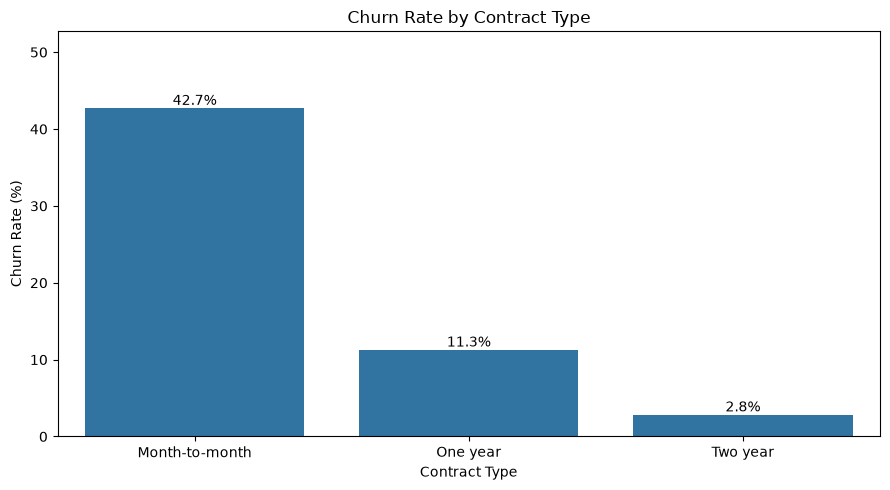


[2] CONTRACT VS OVERALL CHURN
----------------------------------------------------------------------
                customers  churned  churn_rate  difference_vs_overall
Contract                                                             
Month-to-month       3875     1655       42.71                  16.17
One year             1473      166       11.27                 -15.27
Two year             1695       48        2.83                 -23.71

[3] KEY FINDING
----------------------------------------------------------------------
Highest churn: Month-to-month (42.71%)
Lowest churn:  Two year (2.83%)

Overall churn rate: 26.54%

EDA PART 2 COMPLETE


In [8]:
# ============================================================
# EDA PART 2: CHURN BY CONTRACT TYPE
# ============================================================

print("=" * 70)
print("EDA PART 2: CHURN BY CONTRACT TYPE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Calculate churn by contract
# ------------------------------------------------------------

contract_churn = (
    clean_df
    .groupby("Contract")
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum")
    )
)

contract_churn["churn_rate"] = (
    contract_churn["churned"]
    / contract_churn["customers"]
    * 100
)

contract_churn = contract_churn.sort_values(
    "churn_rate",
    ascending=False
)

print("\n[1] CHURN BY CONTRACT TYPE")
print("-" * 70)

print(contract_churn.round(2))


# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_churn.reset_index(),
    x="Contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    contract_churn["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Compare each contract against overall churn
# ------------------------------------------------------------

print("\n[2] CONTRACT VS OVERALL CHURN")
print("-" * 70)

overall_churn_rate = clean_df["Churn_binary"].mean() * 100

contract_comparison = contract_churn.copy()

contract_comparison["difference_vs_overall"] = (
    contract_comparison["churn_rate"]
    - overall_churn_rate
)

print(
    contract_comparison[
        [
            "customers",
            "churned",
            "churn_rate",
            "difference_vs_overall"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 4. Identify highest and lowest churn contracts
# ------------------------------------------------------------

highest_contract = contract_churn["churn_rate"].idxmax()
highest_rate = contract_churn["churn_rate"].max()

lowest_contract = contract_churn["churn_rate"].idxmin()
lowest_rate = contract_churn["churn_rate"].min()

print("\n[3] KEY FINDING")
print("-" * 70)

print(
    f"Highest churn: {highest_contract} "
    f"({highest_rate:.2f}%)"
)

print(
    f"Lowest churn:  {lowest_contract} "
    f"({lowest_rate:.2f}%)"
)

print(
    f"\nOverall churn rate: {overall_churn_rate:.2f}%"
)

print("\n" + "=" * 70)
print("EDA PART 2 COMPLETE")
print("=" * 70)

EDA PART 3: CHURN BY CUSTOMER TENURE

[1] CHURN BY TENURE GROUP
----------------------------------------------------------------------
              customers  churned  churn_rate
tenure_group                                
0-6 months         1481      784       52.94
7-12 months         705      253       35.89
13-24 months       1024      294       28.71
25-48 months       1594      325       20.39
49-60 months        832      120       14.42
61-72 months       1407       93        6.61


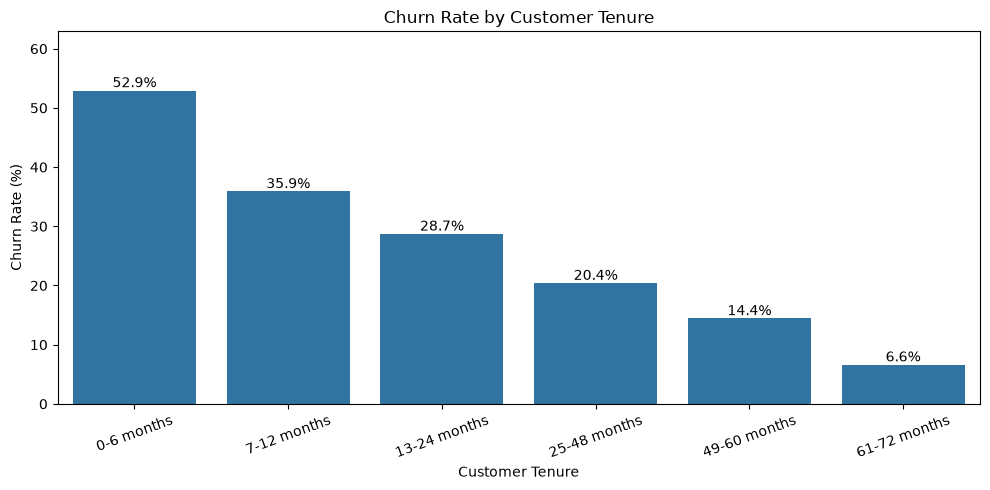


[2] AVERAGE TENURE BY CHURN STATUS
----------------------------------------------------------------------
       count   mean  median  min  max
Churn                                
No      5174  37.57    38.0    0   72
Yes     1869  17.98    10.0    1   72

[3] KEY FINDING
----------------------------------------------------------------------
Highest churn group: 0-6 months (52.94%)
Lowest churn group: 61-72 months (6.61%)

EDA PART 3 COMPLETE


In [9]:
# ============================================================
# EDA PART 3: CHURN BY CUSTOMER TENURE
# ============================================================

print("=" * 70)
print("EDA PART 3: CHURN BY CUSTOMER TENURE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create tenure groups
# ------------------------------------------------------------

clean_df["tenure_group"] = pd.cut(
    clean_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 60, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61-72 months"
    ]
)


# ------------------------------------------------------------
# 2. Calculate churn by tenure group
# ------------------------------------------------------------

tenure_churn = (
    clean_df
    .groupby(
        "tenure_group",
        observed=True
    )
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum")
    )
)

tenure_churn["churn_rate"] = (
    tenure_churn["churned"]
    / tenure_churn["customers"]
    * 100
)

print("\n[1] CHURN BY TENURE GROUP")
print("-" * 70)

print(
    tenure_churn.round(2)
)


# ------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_churn.reset_index(),
    x="tenure_group",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    tenure_churn["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Compare average tenure
# ------------------------------------------------------------

print("\n[2] AVERAGE TENURE BY CHURN STATUS")
print("-" * 70)

average_tenure = (
    clean_df
    .groupby("Churn")["tenure"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .round(2)
)

print(average_tenure)


# ------------------------------------------------------------
# 5. Identify highest-risk tenure group
# ------------------------------------------------------------

highest_tenure_risk = tenure_churn[
    "churn_rate"
].idxmax()

highest_tenure_rate = tenure_churn[
    "churn_rate"
].max()

lowest_tenure_risk = tenure_churn[
    "churn_rate"
].idxmin()

lowest_tenure_rate = tenure_churn[
    "churn_rate"
].min()


print("\n[3] KEY FINDING")
print("-" * 70)

print(
    f"Highest churn group: "
    f"{highest_tenure_risk} "
    f"({highest_tenure_rate:.2f}%)"
)

print(
    f"Lowest churn group: "
    f"{lowest_tenure_risk} "
    f"({lowest_tenure_rate:.2f}%)"
)


print("\n" + "=" * 70)
print("EDA PART 3 COMPLETE")
print("=" * 70)

EDA PART 4: CHURN BY MONTHLY CHARGES

[1] CHURN BY MONTHLY CHARGE
----------------------------------------------------------------------
                      customers  churned  churn_rate
monthly_charge_group                                
$0-$30                     1653      162        9.80
$30-$50                     646      199       30.80
$50-$70                    1161      241       20.76
$70-$90                    1844      697       37.80
$90+                       1739      570       32.78


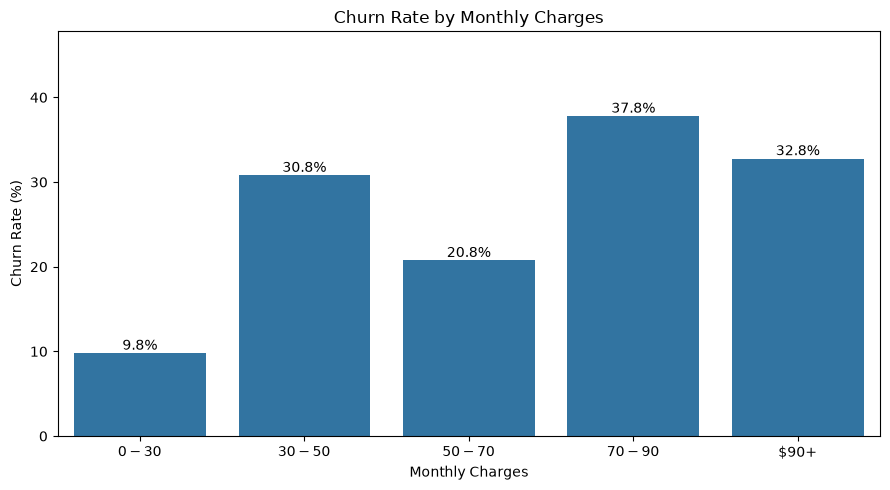


[2] AVERAGE MONTHLY CHARGES BY CHURN STATUS
----------------------------------------------------------------------
       count   mean  median    min     max
Churn                                     
No      5174  61.27   64.43  18.25  118.75
Yes     1869  74.44   79.65  18.85  118.35

[3] KEY FINDING
----------------------------------------------------------------------
Highest churn group: $70-$90 (37.80%)
Lowest churn group: $0-$30 (9.80%)

EDA PART 4 COMPLETE


In [10]:
# ============================================================
# EDA PART 4: CHURN BY MONTHLY CHARGES
# ============================================================

print("=" * 70)
print("EDA PART 4: CHURN BY MONTHLY CHARGES")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create monthly charge groups
# ------------------------------------------------------------

clean_df["monthly_charge_group"] = pd.cut(
    clean_df["MonthlyCharges"],
    bins=[0, 30, 50, 70, 90, 120],
    labels=[
        "$0-$30",
        "$30-$50",
        "$50-$70",
        "$70-$90",
        "$90+"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 2. Calculate churn by charge group
# ------------------------------------------------------------

charge_churn = (
    clean_df
    .groupby(
        "monthly_charge_group",
        observed=True
    )
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum")
    )
)

charge_churn["churn_rate"] = (
    charge_churn["churned"]
    / charge_churn["customers"]
    * 100
)

print("\n[1] CHURN BY MONTHLY CHARGE")
print("-" * 70)

print(
    charge_churn.round(2)
)


# ------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=charge_churn.reset_index(),
    x="monthly_charge_group",
    y="churn_rate"
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    charge_churn["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Compare average charges by churn status
# ------------------------------------------------------------

print("\n[2] AVERAGE MONTHLY CHARGES BY CHURN STATUS")
print("-" * 70)

charge_comparison = (
    clean_df
    .groupby("Churn")["MonthlyCharges"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .round(2)
)

print(charge_comparison)


# ------------------------------------------------------------
# 5. Identify highest and lowest charge groups
# ------------------------------------------------------------

highest_charge_risk = charge_churn["churn_rate"].idxmax()
highest_charge_rate = charge_churn["churn_rate"].max()

lowest_charge_risk = charge_churn["churn_rate"].idxmin()
lowest_charge_rate = charge_churn["churn_rate"].min()


print("\n[3] KEY FINDING")
print("-" * 70)

print(
    f"Highest churn group: "
    f"{highest_charge_risk} "
    f"({highest_charge_rate:.2f}%)"
)

print(
    f"Lowest churn group: "
    f"{lowest_charge_risk} "
    f"({lowest_charge_rate:.2f}%)"
)

print("\n" + "=" * 70)
print("EDA PART 4 COMPLETE")
print("=" * 70)

EDA PART 5: CHURN BY INTERNET SERVICE

[1] CHURN BY INTERNET SERVICE
----------------------------------------------------------------------
                 customers  churned  avg_monthly_charges  churn_rate
InternetService                                                     
Fiber optic           3096     1297                91.50       41.89
DSL                   2421      459                58.10       18.96
No                    1526      113                21.08        7.40


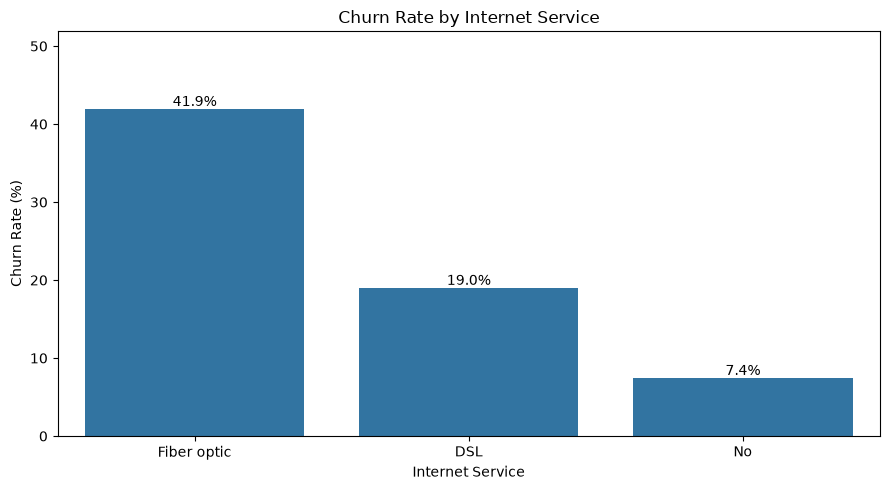


[2] INTERNET SERVICE AND MONTHLY CHARGES
----------------------------------------------------------------------
                 count   mean  median    min     max
InternetService                                     
DSL               2421  58.10   56.15  23.45   94.80
Fiber optic       3096  91.50   91.68  67.75  118.75
No                1526  21.08   20.15  18.25   26.90

[3] KEY FINDING
----------------------------------------------------------------------
Highest churn: Fiber optic (41.89%)
Lowest churn: No (7.40%)

EDA PART 5 COMPLETE


In [11]:
# ============================================================
# EDA PART 5: CHURN BY INTERNET SERVICE
# ============================================================

print("=" * 70)
print("EDA PART 5: CHURN BY INTERNET SERVICE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Churn by Internet Service
# ------------------------------------------------------------

internet_churn = (
    clean_df
    .groupby("InternetService")
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum"),
        avg_monthly_charges=("MonthlyCharges", "mean")
    )
)

internet_churn["churn_rate"] = (
    internet_churn["churned"]
    / internet_churn["customers"]
    * 100
)

internet_churn = internet_churn.sort_values(
    "churn_rate",
    ascending=False
)

print("\n[1] CHURN BY INTERNET SERVICE")
print("-" * 70)

print(
    internet_churn.round(2)
)


# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=internet_churn.reset_index(),
    x="InternetService",
    y="churn_rate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    internet_churn["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Compare monthly charges
# ------------------------------------------------------------

print("\n[2] INTERNET SERVICE AND MONTHLY CHARGES")
print("-" * 70)

internet_charges = (
    clean_df
    .groupby("InternetService")["MonthlyCharges"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .round(2)
)

print(internet_charges)


# ------------------------------------------------------------
# 4. Key finding
# ------------------------------------------------------------

highest_internet_risk = internet_churn["churn_rate"].idxmax()
highest_internet_rate = internet_churn["churn_rate"].max()

lowest_internet_risk = internet_churn["churn_rate"].idxmin()
lowest_internet_rate = internet_churn["churn_rate"].min()

print("\n[3] KEY FINDING")
print("-" * 70)

print(
    f"Highest churn: {highest_internet_risk} "
    f"({highest_internet_rate:.2f}%)"
)

print(
    f"Lowest churn: {lowest_internet_risk} "
    f"({lowest_internet_rate:.2f}%)"
)

print("\n" + "=" * 70)
print("EDA PART 5 COMPLETE")
print("=" * 70)

EDA PART 6: CHURN BY PAYMENT METHOD

[1] CHURN BY PAYMENT METHOD
----------------------------------------------------------------------
                           customers  churned  avg_monthly_charges  churn_rate
PaymentMethod                                                                 
Electronic check                2365     1071                76.26       45.29
Mailed check                    1612      308                43.92       19.11
Bank transfer (automatic)       1544      258                67.19       16.71
Credit card (automatic)         1522      232                66.51       15.24


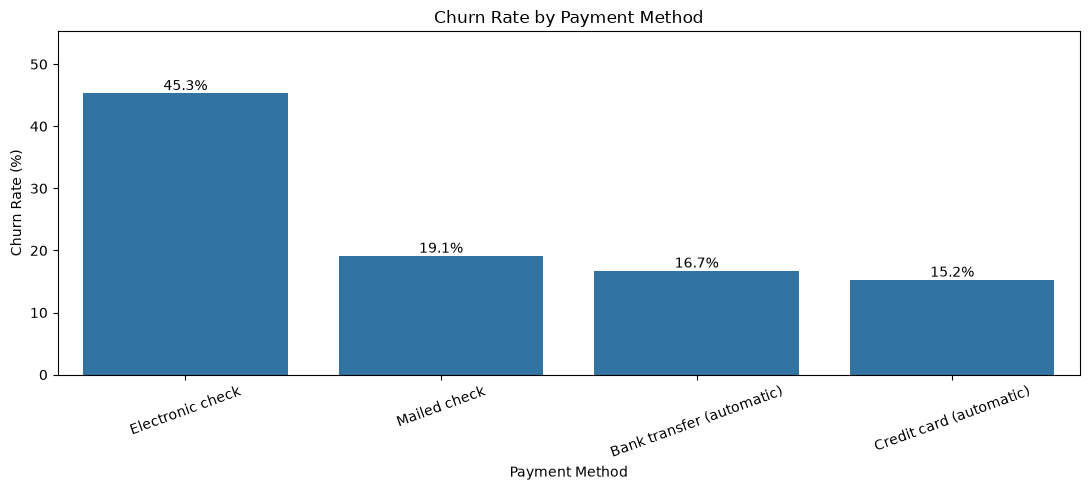


[2] PAYMENT METHOD AND TENURE
----------------------------------------------------------------------
                           count   mean  median
PaymentMethod                                  
Bank transfer (automatic)   1544  43.66    48.0
Credit card (automatic)     1522  43.27    47.0
Electronic check            2365  25.17    18.0
Mailed check                1612  21.83    15.0

[3] KEY FINDING
----------------------------------------------------------------------
Highest churn: Electronic check (45.29%)
Lowest churn: Credit card (automatic) (15.24%)

EDA PART 6 COMPLETE


In [12]:
# ============================================================
# EDA PART 6: CHURN BY PAYMENT METHOD
# ============================================================

print("=" * 70)
print("EDA PART 6: CHURN BY PAYMENT METHOD")
print("=" * 70)


# ------------------------------------------------------------
# 1. Churn by payment method
# ------------------------------------------------------------

payment_churn = (
    clean_df
    .groupby("PaymentMethod")
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum"),
        avg_monthly_charges=("MonthlyCharges", "mean")
    )
)

payment_churn["churn_rate"] = (
    payment_churn["churned"]
    / payment_churn["customers"]
    * 100
)

payment_churn = payment_churn.sort_values(
    "churn_rate",
    ascending=False
)

print("\n[1] CHURN BY PAYMENT METHOD")
print("-" * 70)

print(
    payment_churn.round(2)
)


# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=payment_churn.reset_index(),
    x="PaymentMethod",
    y="churn_rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    payment_churn["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Payment method and customer tenure
# ------------------------------------------------------------

print("\n[2] PAYMENT METHOD AND TENURE")
print("-" * 70)

payment_tenure = (
    clean_df
    .groupby("PaymentMethod")["tenure"]
    .agg(
        ["count", "mean", "median"]
    )
    .round(2)
)

print(payment_tenure)


# ------------------------------------------------------------
# 4. Identify highest and lowest risk
# ------------------------------------------------------------

highest_payment_risk = payment_churn["churn_rate"].idxmax()
highest_payment_rate = payment_churn["churn_rate"].max()

lowest_payment_risk = payment_churn["churn_rate"].idxmin()
lowest_payment_rate = payment_churn["churn_rate"].min()


print("\n[3] KEY FINDING")
print("-" * 70)

print(
    f"Highest churn: {highest_payment_risk} "
    f"({highest_payment_rate:.2f}%)"
)

print(
    f"Lowest churn: {lowest_payment_risk} "
    f"({lowest_payment_rate:.2f}%)"
)

print("\n" + "=" * 70)
print("EDA PART 6 COMPLETE")
print("=" * 70)


EDA PART 7: SUPPORT AND SECURITY SERVICES

[1] CHURN BY ADDITIONAL SERVICES
----------------------------------------------------------------------

OnlineSecurity
           category  customers  churned  churn_rate
                 No     3498.0   1461.0       41.77
No internet service     1526.0    113.0        7.40
                Yes     2019.0    295.0       14.61

OnlineBackup
           category  customers  churned  churn_rate
                 No     3088.0   1233.0       39.93
No internet service     1526.0    113.0        7.40
                Yes     2429.0    523.0       21.53

DeviceProtection
           category  customers  churned  churn_rate
                 No     3095.0   1211.0       39.13
No internet service     1526.0    113.0        7.40
                Yes     2422.0    545.0       22.50

TechSupport
           category  customers  churned  churn_rate
                 No     3473.0   1446.0       41.64
No internet service     1526.0    113.0        7.40
            

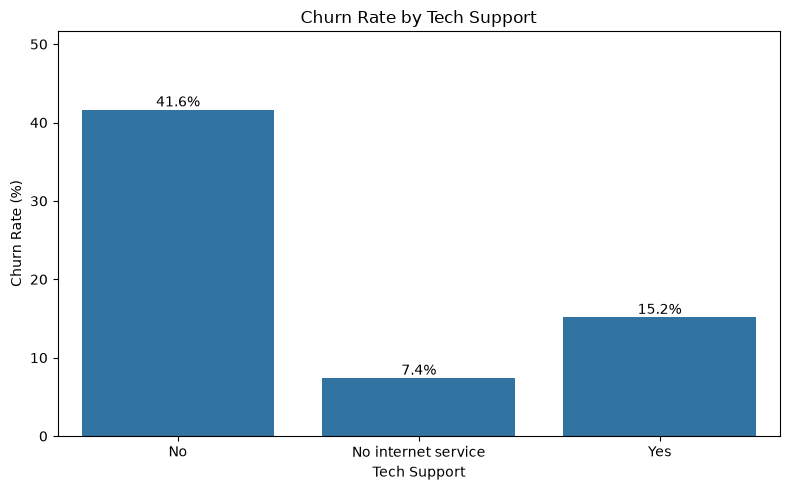

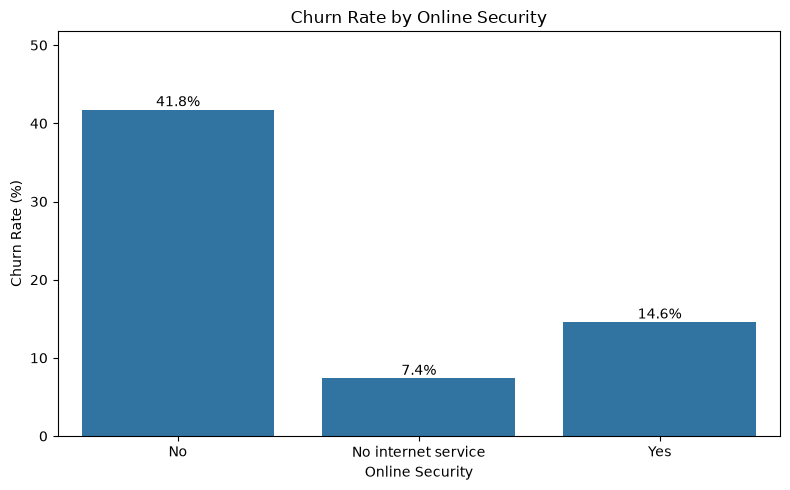


EDA PART 7 COMPLETE


In [13]:
# ============================================================
# EDA PART 7: SUPPORT AND SECURITY SERVICES
# ============================================================

print("=" * 70)
print("EDA PART 7: SUPPORT AND SECURITY SERVICES")
print("=" * 70)


# ------------------------------------------------------------
# 1. Define services to analyze
# ------------------------------------------------------------

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


# ------------------------------------------------------------
# 2. Calculate churn for each service
# ------------------------------------------------------------

service_results = []

for service in service_columns:

    service_summary = (
        clean_df
        .groupby(service)
        .agg(
            customers=("customerID", "count"),
            churned=("Churn_binary", "sum")
        )
    )

    service_summary["churn_rate"] = (
        service_summary["churned"]
        / service_summary["customers"]
        * 100
    )

    for category, row in service_summary.iterrows():

        service_results.append({
            "service": service,
            "category": category,
            "customers": row["customers"],
            "churned": row["churned"],
            "churn_rate": row["churn_rate"]
        })


service_churn = pd.DataFrame(service_results)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("\n[1] CHURN BY ADDITIONAL SERVICES")
print("-" * 70)

for service in service_columns:

    print(f"\n{service}")

    result = service_churn[
        service_churn["service"] == service
    ][
        [
            "category",
            "customers",
            "churned",
            "churn_rate"
        ]
    ]

    print(
        result.round(2).to_string(index=False)
    )


# ------------------------------------------------------------
# 4. Focus specifically on Tech Support
# ------------------------------------------------------------

print("\n[2] TECH SUPPORT")
print("-" * 70)

tech_support = (
    clean_df
    .groupby("TechSupport")
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum")
    )
)

tech_support["churn_rate"] = (
    tech_support["churned"]
    / tech_support["customers"]
    * 100
)

print(
    tech_support.round(2)
)


# ------------------------------------------------------------
# 5. Focus specifically on Online Security
# ------------------------------------------------------------

print("\n[3] ONLINE SECURITY")
print("-" * 70)

online_security = (
    clean_df
    .groupby("OnlineSecurity")
    .agg(
        customers=("customerID", "count"),
        churned=("Churn_binary", "sum")
    )
)

online_security["churn_rate"] = (
    online_security["churned"]
    / online_security["customers"]
    * 100
)

print(
    online_security.round(2)
)


# ------------------------------------------------------------
# 6. Visualize Tech Support
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tech_support.reset_index(),
    x="TechSupport",
    y="churn_rate"
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    tech_support["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Visualize Online Security
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=online_security.reset_index(),
    x="OnlineSecurity",
    y="churn_rate"
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.ylim(
    0,
    online_security["churn_rate"].max() + 10
)

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("EDA PART 7 COMPLETE")
print("=" * 70)

In [14]:
# ============================================================
# STAGE 4: MODELING DATA PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

print("=" * 70)
print("MODELING DATA PREPARATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create modeling dataset
# ------------------------------------------------------------

model_df = clean_df.copy()

print("\n[1] ORIGINAL MODELING DATASET")
print("-" * 70)

print(f"Rows:    {model_df.shape[0]:,}")
print(f"Columns: {model_df.shape[1]:,}")


# ------------------------------------------------------------
# 2. Remove analysis-only columns
# ------------------------------------------------------------

# These columns should NOT be used as predictive features:
#
# customerID        -> identifier, not a meaningful predictor
# Churn             -> original text version of our target
# Churn_binary      -> target variable, kept separately
# tenure_group      -> created specifically for EDA
# monthly_charge_group -> created specifically for EDA

columns_to_remove = [
    "customerID",
    "Churn",
    "tenure_group",
    "monthly_charge_group"
]

model_df = model_df.drop(
    columns=columns_to_remove
)


# ------------------------------------------------------------
# 3. Separate features and target
# ------------------------------------------------------------

X = model_df.drop(
    columns=["Churn_binary"]
)

y = model_df["Churn_binary"]


print("\n[2] FEATURES AND TARGET")
print("-" * 70)

print(f"Features: {X.shape[1]}")
print(f"Target:   Churn_binary")

print("\nTarget distribution:")
print(
    y.value_counts()
)

print("\nTarget percentages:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)


# ------------------------------------------------------------
# 4. Identify numerical and categorical features
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()


print("\n[3] FEATURE TYPES")
print("-" * 70)

print(
    f"Numerical features:   {len(numerical_features)}"
)

print(
    f"Categorical features: {len(categorical_features)}"
)

print("\nNumerical:")
print(numerical_features)

print("\nCategorical:")
print(categorical_features)


# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n[4] TRAIN / TEST SPLIT")
print("-" * 70)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

print(
    f"\nTraining churn rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Testing churn rate:  "
    f"{y_test.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# 6. Create preprocessing pipeline
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


# ------------------------------------------------------------
# 7. Final checks
# ------------------------------------------------------------

print("\n[5] FINAL CHECKS")
print("-" * 70)

print(
    f"Missing values in X: "
    f"{X.isnull().sum().sum()}"
)

print(
    f"Missing values in y: "
    f"{y.isnull().sum()}"
)

print(
    f"Duplicate rows in X: "
    f"{X.duplicated().sum()}"
)


print("\n" + "=" * 70)
print("MODELING DATA PREPARATION COMPLETE")
print("=" * 70)

MODELING DATA PREPARATION

[1] ORIGINAL MODELING DATASET
----------------------------------------------------------------------
Rows:    7,043
Columns: 24

[2] FEATURES AND TARGET
----------------------------------------------------------------------
Features: 19
Target:   Churn_binary

Target distribution:
Churn_binary
0    5174
1    1869
Name: count, dtype: int64

Target percentages:
Churn_binary
0    73.46
1    26.54
Name: proportion, dtype: float64

[3] FEATURE TYPES
----------------------------------------------------------------------
Numerical features:   4
Categorical features: 15

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

[4] TRAIN / TEST SPLIT
----------------------------------------------------

LOGISTIC REGRESSION CHURN MODEL

[1] TRAINING MODEL
----------------------------------------------------------------------


c:\Users\admin\miniconda3\envs\customer-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model trained successfully.

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.8048 (80.48%)
Precision: 0.6562 (65.62%)
Recall:    0.5561 (55.61%)
F1 Score:  0.6020
ROC-AUC:   0.8427

[3] CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


[4] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Retained  Churned
Actual Retained       926      109
Actual Churned        166      208

[5] MODEL COEFFICIENTS
-------------------------------------------------------------------

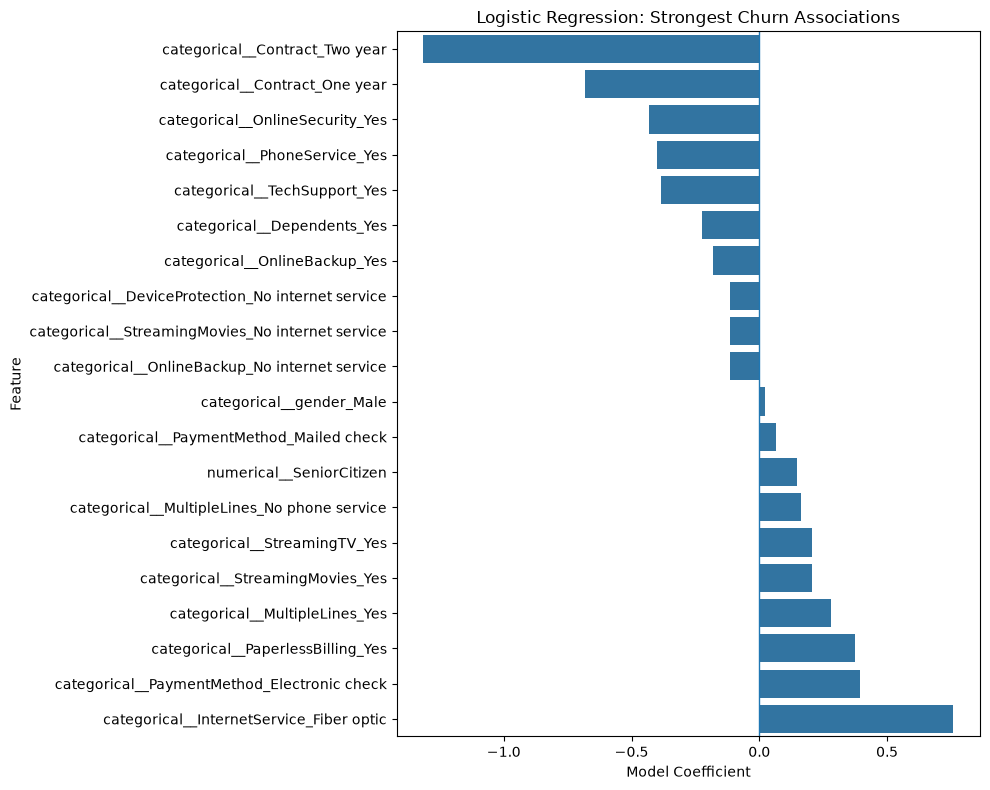


LOGISTIC REGRESSION COMPLETE
ROC-AUC: 0.8427
Accuracy: 80.48%
Recall: 55.61%
F1 Score: 0.6020


In [15]:
# ============================================================
# STAGE 5: LOGISTIC REGRESSION CHURN MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("LOGISTIC REGRESSION CHURN MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create model pipeline
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Train model
# ------------------------------------------------------------

print("\n[1] TRAINING MODEL")
print("-" * 70)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------
# 4. Calculate performance metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\n[3] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)


# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n[4] CONFUSION MATRIX")
print("-" * 70)

print(
    "                 Predicted"
)

print(
    "                 Retained  Churned"
)

print(
    f"Actual Retained  {cm[0,0]:>8}  {cm[0,1]:>7}"
)

print(
    f"Actual Churned   {cm[1,0]:>8}  {cm[1,1]:>7}"
)


# ------------------------------------------------------------
# 7. Extract model coefficients
# ------------------------------------------------------------

print("\n[5] MODEL COEFFICIENTS")
print("-" * 70)

# Get transformed feature names
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})


# Odds ratio
coefficient_df["odds_ratio"] = np.exp(
    coefficient_df["coefficient"]
)


# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    "coefficient",
    ascending=False
)


print("\nTop factors associated with HIGHER churn:")
print("-" * 70)

print(
    coefficient_df.head(15).to_string(
        index=False
    )
)


print("\nTop factors associated with LOWER churn:")
print("-" * 70)

print(
    coefficient_df.tail(15).sort_values(
        "coefficient"
    ).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Coefficient visualization
# ------------------------------------------------------------

top_coefficients = pd.concat([
    coefficient_df.head(10),
    coefficient_df.tail(10)
])

top_coefficients = (
    top_coefficients
    .drop_duplicates("feature")
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Logistic Regression: Strongest Churn Associations"
)

plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION COMPLETE")
print("=" * 70)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print(
    f"Recall: {recall * 100:.2f}%"
)

print(
    f"F1 Score: {f1:.4f}"
)

print("=" * 70)

In [16]:
# ============================================================
# STAGE 5B: IMPROVED LOGISTIC REGRESSION
# Scale numerical features to resolve convergence warning
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("IMPROVED LOGISTIC REGRESSION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create improved preprocessor
# ------------------------------------------------------------

scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)


# ------------------------------------------------------------
# 2. Create improved Logistic Regression model
# ------------------------------------------------------------

logistic_model_scaled = Pipeline(
    steps=[
        (
            "preprocessor",
            scaled_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 3. Train
# ------------------------------------------------------------

print("\n[1] TRAINING")
print("-" * 70)

logistic_model_scaled.fit(
    X_train,
    y_train
)

print("Model trained successfully.")


# ------------------------------------------------------------
# 4. Predictions
# ------------------------------------------------------------

y_pred_scaled = logistic_model_scaled.predict(
    X_test
)

y_probability_scaled = (
    logistic_model_scaled
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

accuracy_scaled = accuracy_score(
    y_test,
    y_pred_scaled
)

precision_scaled = precision_score(
    y_test,
    y_pred_scaled
)

recall_scaled = recall_score(
    y_test,
    y_pred_scaled
)

f1_scaled = f1_score(
    y_test,
    y_pred_scaled
)

roc_auc_scaled = roc_auc_score(
    y_test,
    y_probability_scaled
)


print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy:  {accuracy_scaled:.4f} "
    f"({accuracy_scaled * 100:.2f}%)"
)

print(
    f"Precision: {precision_scaled:.4f} "
    f"({precision_scaled * 100:.2f}%)"
)

print(
    f"Recall:    {recall_scaled:.4f} "
    f"({recall_scaled * 100:.2f}%)"
)

print(
    f"F1 Score:  {f1_scaled:.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_scaled:.4f}"
)


# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

cm_scaled = confusion_matrix(
    y_test,
    y_pred_scaled
)

print("\n[3] CONFUSION MATRIX")
print("-" * 70)

print(
    "                 Predicted"
)

print(
    "                 Retained  Churned"
)

print(
    f"Actual Retained  {cm_scaled[0,0]:>8}  "
    f"{cm_scaled[0,1]:>7}"
)

print(
    f"Actual Churned   {cm_scaled[1,0]:>8}  "
    f"{cm_scaled[1,1]:>7}"
)


# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print("\n[4] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        y_pred_scaled,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)


# ------------------------------------------------------------
# 8. Compare with original model
# ------------------------------------------------------------

print("\n[5] BEFORE VS AFTER")
print("-" * 70)

comparison_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Original": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Scaled": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled,
        roc_auc_scaled
    ]
})

comparison_metrics["Improvement"] = (
    comparison_metrics["Scaled"]
    - comparison_metrics["Original"]
)

print(
    comparison_metrics.round(4).to_string(
        index=False
    )
)


print("\n" + "=" * 70)
print("IMPROVED LOGISTIC REGRESSION COMPLETE")
print("=" * 70)

IMPROVED LOGISTIC REGRESSION

[1] TRAINING
----------------------------------------------------------------------
Model trained successfully.

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.8070 (80.70%)
Precision: 0.6604 (66.04%)
Recall:    0.5615 (56.15%)
F1 Score:  0.6069
ROC-AUC:   0.8422

[3] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Retained  Churned
Actual Retained       927      108
Actual Churned        164      210

[4] CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      140

RANDOM FOREST CHURN MODEL

[1] TRAINING MODEL
----------------------------------------------------------------------
Random Forest model trained successfully.

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.7587 (75.87%)
Precision: 0.5307 (53.07%)
Recall:    0.7861 (78.61%)
F1 Score:  0.6336
ROC-AUC:   0.8437

[3] CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.91      0.75      0.82      1035
     Churned       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


[4] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Retained  Churned
Actual Retained       775      260
Actual Churned 

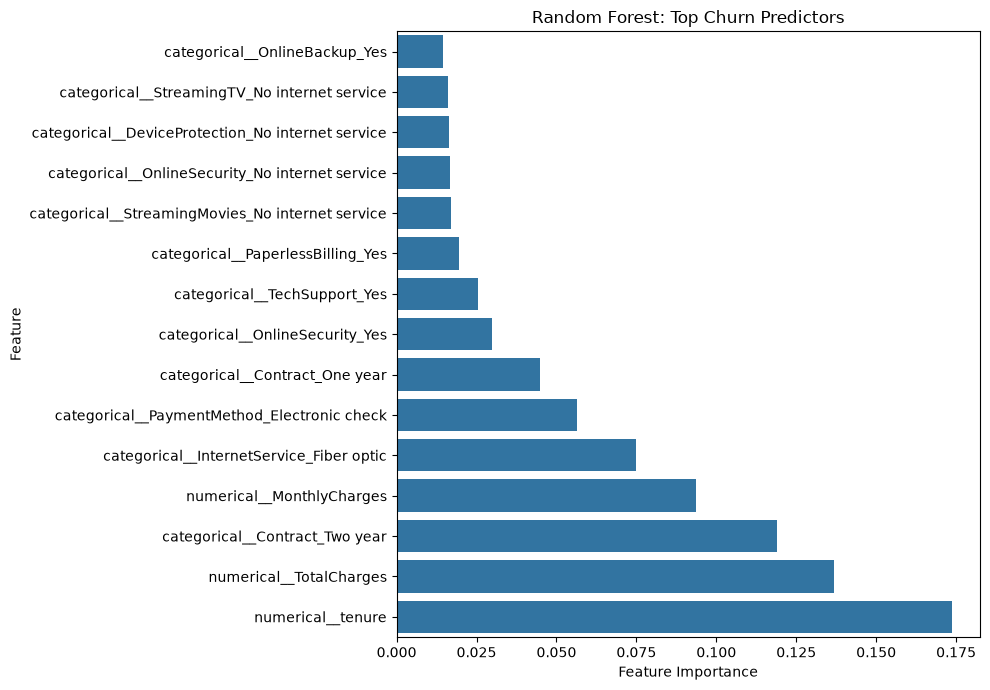


[6] LOGISTIC REGRESSION VS RANDOM FOREST
----------------------------------------------------------------------
   Metric  Logistic Regression  Random Forest
 Accuracy               0.8070         0.7587
Precision               0.6604         0.5307
   Recall               0.5615         0.7861
 F1 Score               0.6069         0.6336
  ROC-AUC               0.8422         0.8437

RANDOM FOREST COMPLETE


In [17]:
# ============================================================
# STAGE 6: RANDOM FOREST CHURN MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("RANDOM FOREST CHURN MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create Random Forest pipeline
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Train model
# ------------------------------------------------------------

print("\n[1] TRAINING MODEL")
print("-" * 70)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

rf_pred = random_forest_model.predict(
    X_test
)

rf_probability = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 4. Calculate performance metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)


print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy:  {rf_accuracy:.4f} "
    f"({rf_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {rf_precision:.4f} "
    f"({rf_precision * 100:.2f}%)"
)

print(
    f"Recall:    {rf_recall:.4f} "
    f"({rf_recall * 100:.2f}%)"
)

print(
    f"F1 Score:  {rf_f1:.4f}"
)

print(
    f"ROC-AUC:   {rf_roc_auc:.4f}"
)


# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\n[3] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)


# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\n[4] CONFUSION MATRIX")
print("-" * 70)

print(
    "                 Predicted"
)

print(
    "                 Retained  Churned"
)

print(
    f"Actual Retained  {rf_cm[0,0]:>8}  "
    f"{rf_cm[0,1]:>7}"
)

print(
    f"Actual Churned   {rf_cm[1,0]:>8}  "
    f"{rf_cm[1,1]:>7}"
)


# ------------------------------------------------------------
# 7. Feature importance
# ------------------------------------------------------------

print("\n[5] FEATURE IMPORTANCE")
print("-" * 70)

rf_feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importances = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances
})

rf_importance_df = rf_importance_df.sort_values(
    "importance",
    ascending=False
)

print(
    rf_importance_df.head(20).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Feature importance visualization
# ------------------------------------------------------------

top_rf_features = (
    rf_importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf_features,
    x="importance",
    y="feature"
)

plt.title(
    "Random Forest: Top Churn Predictors"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Compare models
# ------------------------------------------------------------

print("\n[6] LOGISTIC REGRESSION VS RANDOM FOREST")
print("-" * 70)

model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled,
        roc_auc_scaled
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print(
    model_comparison.round(4).to_string(
        index=False
    )
)


print("\n" + "=" * 70)
print("RANDOM FOREST COMPLETE")
print("=" * 70)


GRADIENT BOOSTING CHURN MODEL

[1] TRAINING MODEL
----------------------------------------------------------------------
Gradient Boosting model trained successfully.

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.7963 (79.63%)
Precision: 0.6495 (64.95%)
Recall:    0.5053 (50.53%)
F1 Score:  0.5684
ROC-AUC:   0.8438

[3] CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


[4] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Retained  Churned
Actual Retained       933      102
Actual 

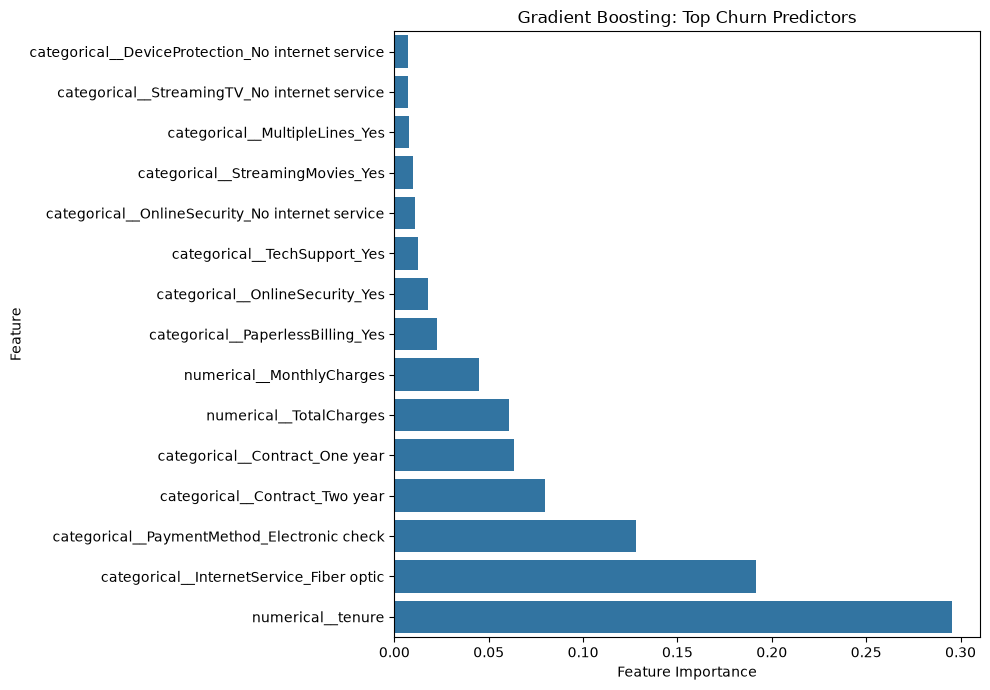


[6] MODEL COMPARISON
----------------------------------------------------------------------
   Metric  Logistic Regression  Random Forest  Gradient Boosting
 Accuracy               0.8070         0.7587             0.7963
Precision               0.6604         0.5307             0.6495
   Recall               0.5615         0.7861             0.5053
 F1 Score               0.6069         0.6336             0.5684
  ROC-AUC               0.8422         0.8437             0.8438

[7] BEST MODEL BY ACCURACY
----------------------------------------------------------------------
Logistic Regression: 80.70%

[8] BEST MODEL BY ROC-AUC
----------------------------------------------------------------------
Gradient Boosting: 0.8438

GRADIENT BOOSTING COMPLETE


In [18]:
# ============================================================
# STAGE 7: GRADIENT BOOSTING CHURN MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

print("=" * 70)
print("GRADIENT BOOSTING CHURN MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create Gradient Boosting model
# ------------------------------------------------------------

gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Train model
# ------------------------------------------------------------

print("\n[1] TRAINING MODEL")
print("-" * 70)

gradient_boosting_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

gb_pred = gradient_boosting_model.predict(
    X_test
)

gb_probability = (
    gradient_boosting_model
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 4. Calculate performance metrics
# ------------------------------------------------------------

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

gb_precision = precision_score(
    y_test,
    gb_pred
)

gb_recall = recall_score(
    y_test,
    gb_pred
)

gb_f1 = f1_score(
    y_test,
    gb_pred
)

gb_roc_auc = roc_auc_score(
    y_test,
    gb_probability
)


print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy:  {gb_accuracy:.4f} "
    f"({gb_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {gb_precision:.4f} "
    f"({gb_precision * 100:.2f}%)"
)

print(
    f"Recall:    {gb_recall:.4f} "
    f"({gb_recall * 100:.2f}%)"
)

print(
    f"F1 Score:  {gb_f1:.4f}"
)

print(
    f"ROC-AUC:   {gb_roc_auc:.4f}"
)


# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\n[3] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        gb_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)


# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

gb_cm = confusion_matrix(
    y_test,
    gb_pred
)

print("\n[4] CONFUSION MATRIX")
print("-" * 70)

print(
    "                 Predicted"
)

print(
    "                 Retained  Churned"
)

print(
    f"Actual Retained  {gb_cm[0,0]:>8}  "
    f"{gb_cm[0,1]:>7}"
)

print(
    f"Actual Churned   {gb_cm[1,0]:>8}  "
    f"{gb_cm[1,1]:>7}"
)


# ------------------------------------------------------------
# 7. Feature importance
# ------------------------------------------------------------

print("\n[5] FEATURE IMPORTANCE")
print("-" * 70)

gb_feature_names = (
    gradient_boosting_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

gb_importances = (
    gradient_boosting_model
    .named_steps["model"]
    .feature_importances_
)

gb_importance_df = pd.DataFrame({
    "feature": gb_feature_names,
    "importance": gb_importances
})

gb_importance_df = gb_importance_df.sort_values(
    "importance",
    ascending=False
)

print(
    gb_importance_df.head(20).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Feature importance visualization
# ------------------------------------------------------------

top_gb_features = (
    gb_importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_gb_features,
    x="importance",
    y="feature"
)

plt.title(
    "Gradient Boosting: Top Churn Predictors"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Compare all three models
# ------------------------------------------------------------

print("\n[6] MODEL COMPARISON")
print("-" * 70)

all_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled,
        roc_auc_scaled
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ],
    "Gradient Boosting": [
        gb_accuracy,
        gb_precision,
        gb_recall,
        gb_f1,
        gb_roc_auc
    ]
})

print(
    all_model_comparison.round(4).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. Identify best model by accuracy
# ------------------------------------------------------------

accuracy_results = {
    "Logistic Regression": accuracy_scaled,
    "Random Forest": rf_accuracy,
    "Gradient Boosting": gb_accuracy
}

best_accuracy_model = max(
    accuracy_results,
    key=accuracy_results.get
)

print("\n[7] BEST MODEL BY ACCURACY")
print("-" * 70)

print(
    f"{best_accuracy_model}: "
    f"{accuracy_results[best_accuracy_model] * 100:.2f}%"
)


# ------------------------------------------------------------
# 11. Identify best model by ROC-AUC
# ------------------------------------------------------------

roc_results = {
    "Logistic Regression": roc_auc_scaled,
    "Random Forest": rf_roc_auc,
    "Gradient Boosting": gb_roc_auc
}

best_roc_model = max(
    roc_results,
    key=roc_results.get
)

print("\n[8] BEST MODEL BY ROC-AUC")
print("-" * 70)

print(
    f"{best_roc_model}: "
    f"{roc_results[best_roc_model]:.4f}"
)


print("\n" + "=" * 70)
print("GRADIENT BOOSTING COMPLETE")
print("=" * 70)

In [19]:
# ============================================================
# STAGE 8: HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=" * 70)
print("STAGE 8: HYPERPARAMETER TUNING")
print("=" * 70)


# ============================================================
# PART 1: TUNE RANDOM FOREST
# ============================================================

print("\n[1] RANDOM FOREST TUNING")
print("-" * 70)

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)


rf_parameters = {
    "model__n_estimators": [
        200,
        300,
        500
    ],
    "model__max_depth": [
        8,
        12,
        16,
        None
    ],
    "model__min_samples_leaf": [
        2,
        5,
        10
    ]
}


print("Testing Random Forest parameter combinations...")

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_parameters,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)


print("\nBest Random Forest parameters:")
print(rf_grid.best_params_)

print(
    f"\nBest cross-validation ROC-AUC: "
    f"{rf_grid.best_score_:.4f}"
)


# ============================================================
# PART 2: EVALUATE TUNED RANDOM FOREST
# ============================================================

print("\n[2] TUNED RANDOM FOREST TEST PERFORMANCE")
print("-" * 70)

tuned_rf = rf_grid.best_estimator_

tuned_rf_pred = tuned_rf.predict(
    X_test
)

tuned_rf_probability = (
    tuned_rf.predict_proba(X_test)[:, 1]
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_roc_auc = roc_auc_score(
    y_test,
    tuned_rf_probability
)


print(
    f"Accuracy:  {tuned_rf_accuracy:.4f} "
    f"({tuned_rf_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {tuned_rf_precision:.4f} "
    f"({tuned_rf_precision * 100:.2f}%)"
)

print(
    f"Recall:    {tuned_rf_recall:.4f} "
    f"({tuned_rf_recall * 100:.2f}%)"
)

print(
    f"F1 Score:  {tuned_rf_f1:.4f}"
)

print(
    f"ROC-AUC:   {tuned_rf_roc_auc:.4f}"
)


# ============================================================
# PART 3: TUNE GRADIENT BOOSTING
# ============================================================

print("\n[3] GRADIENT BOOSTING TUNING")
print("-" * 70)

gb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)


gb_parameters = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    "model__learning_rate": [
        0.03,
        0.05,
        0.10
    ],
    "model__max_depth": [
        2,
        3,
        4
    ],
    "model__min_samples_leaf": [
        3,
        5,
        10
    ]
}


print(
    "Testing Gradient Boosting parameter combinations..."
)

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_parameters,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(
    X_train,
    y_train
)


print("\nBest Gradient Boosting parameters:")
print(gb_grid.best_params_)

print(
    f"\nBest cross-validation ROC-AUC: "
    f"{gb_grid.best_score_:.4f}"
)


# ============================================================
# PART 4: EVALUATE TUNED GRADIENT BOOSTING
# ============================================================

print("\n[4] TUNED GRADIENT BOOSTING TEST PERFORMANCE")
print("-" * 70)

tuned_gb = gb_grid.best_estimator_

tuned_gb_pred = tuned_gb.predict(
    X_test
)

tuned_gb_probability = (
    tuned_gb.predict_proba(X_test)[:, 1]
)

tuned_gb_accuracy = accuracy_score(
    y_test,
    tuned_gb_pred
)

tuned_gb_precision = precision_score(
    y_test,
    tuned_gb_pred
)

tuned_gb_recall = recall_score(
    y_test,
    tuned_gb_pred
)

tuned_gb_f1 = f1_score(
    y_test,
    tuned_gb_pred
)

tuned_gb_roc_auc = roc_auc_score(
    y_test,
    tuned_gb_probability
)


print(
    f"Accuracy:  {tuned_gb_accuracy:.4f} "
    f"({tuned_gb_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {tuned_gb_precision:.4f} "
    f"({tuned_gb_precision * 100:.2f}%)"
)

print(
    f"Recall:    {tuned_gb_recall:.4f} "
    f"({tuned_gb_recall * 100:.2f}%)"
)

print(
    f"F1 Score:  {tuned_gb_f1:.4f}"
)

print(
    f"ROC-AUC:   {tuned_gb_roc_auc:.4f}"
)


# ============================================================
# PART 5: FINAL MODEL COMPARISON
# ============================================================

print("\n[5] FINAL MODEL COMPARISON")
print("-" * 70)

final_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Logistic Regression": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled,
        roc_auc_scaled
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ],

    "Tuned Random Forest": [
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1,
        tuned_rf_roc_auc
    ],

    "Gradient Boosting": [
        gb_accuracy,
        gb_precision,
        gb_recall,
        gb_f1,
        gb_roc_auc
    ],

    "Tuned Gradient Boosting": [
        tuned_gb_accuracy,
        tuned_gb_precision,
        tuned_gb_recall,
        tuned_gb_f1,
        tuned_gb_roc_auc
    ]
})


print(
    final_comparison.round(4).to_string(
        index=False
    )
)


# ============================================================
# PART 6: BEST ACCURACY
# ============================================================

accuracy_results = {
    "Logistic Regression": accuracy_scaled,
    "Random Forest": rf_accuracy,
    "Tuned Random Forest": tuned_rf_accuracy,
    "Gradient Boosting": gb_accuracy,
    "Tuned Gradient Boosting": tuned_gb_accuracy
}


best_accuracy_model = max(
    accuracy_results,
    key=accuracy_results.get
)

best_accuracy_value = accuracy_results[
    best_accuracy_model
]


print("\n[6] BEST ACCURACY")
print("-" * 70)

print(
    f"Model: {best_accuracy_model}"
)

print(
    f"Accuracy: {best_accuracy_value * 100:.2f}%"
)


# ============================================================
# PART 7: BEST ROC-AUC
# ============================================================

roc_results = {
    "Logistic Regression": roc_auc_scaled,
    "Random Forest": rf_roc_auc,
    "Tuned Random Forest": tuned_rf_roc_auc,
    "Gradient Boosting": gb_roc_auc,
    "Tuned Gradient Boosting": tuned_gb_roc_auc
}


best_roc_model = max(
    roc_results,
    key=roc_results.get
)

best_roc_value = roc_results[
    best_roc_model
]


print("\n[7] BEST ROC-AUC")
print("-" * 70)

print(
    f"Model: {best_roc_model}"
)

print(
    f"ROC-AUC: {best_roc_value:.4f}"
)


print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING COMPLETE")
print("=" * 70)

STAGE 8: HYPERPARAMETER TUNING

[1] RANDOM FOREST TUNING
----------------------------------------------------------------------
Testing Random Forest parameter combinations...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Random Forest parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 10, 'model__n_estimators': 500}

Best cross-validation ROC-AUC: 0.8475

[2] TUNED RANDOM FOREST TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.7537 (75.37%)
Precision: 0.5241 (52.41%)
Recall:    0.7861 (78.61%)
F1 Score:  0.6289
ROC-AUC:   0.8455

[3] GRADIENT BOOSTING TUNING
----------------------------------------------------------------------
Testing Gradient Boosting parameter combinations...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}

Best cross-va

STAGE 9: MODEL VALIDATION & ERROR ANALYSIS

[1] FINAL BASE MODEL
----------------------------------------------------------------------
Model trained successfully.

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.8062 (80.62%)
Precision: 0.6593 (65.93%)
Recall:    0.5588 (55.88%)
F1 Score:  0.6049
ROC-AUC:   0.8425

[3] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Retained  Churned
Actual Retained       927      108
Actual Churned        165      209

Error interpretation:
Correctly retained:   927
False alarms:         108
Missed churners:      165
Correctly identified: 209

[4] CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.60       374

    accurac

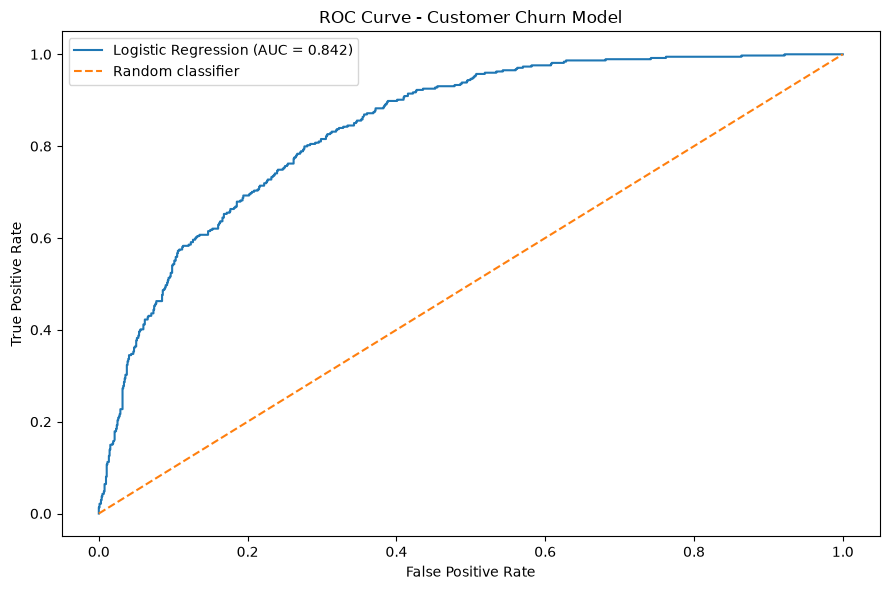


[12] PRECISION-RECALL CURVE
----------------------------------------------------------------------


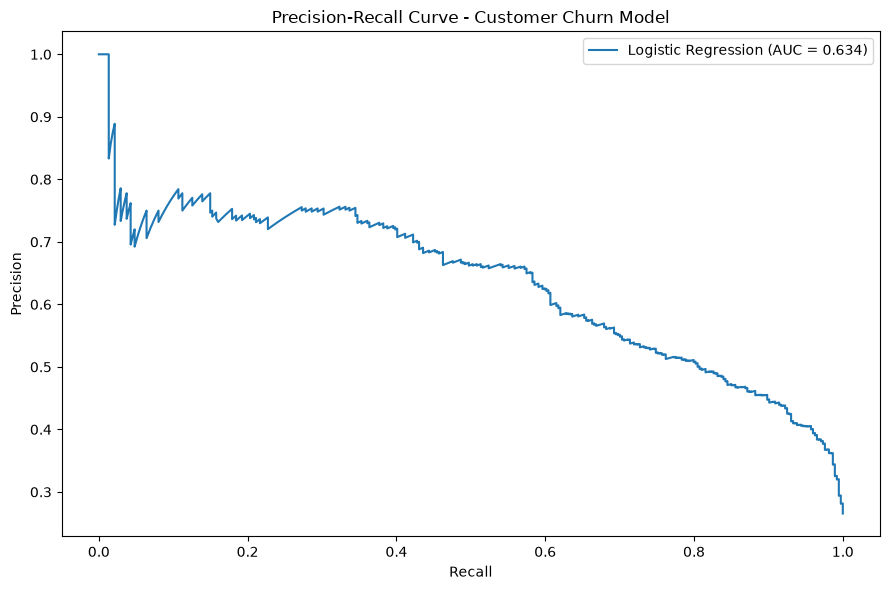


[13] FINAL MODEL INTERPRETATION
----------------------------------------------------------------------
Accuracy:  80.62%
Precision: 65.93%
Recall:    55.88%
F1 Score:  0.6049
ROC-AUC:   0.8425

Best F1 threshold tested: 0.30

Business interpretation:
A lower probability threshold identifies more potential churners, but also creates more false alarms.
A higher threshold produces fewer alerts, but may miss more customers who are actually going to churn.

The appropriate threshold depends on whether the business prioritizes finding as many potential churners as possible or minimizing unnecessary retention interventions.

STAGE 9 COMPLETE


In [21]:
# ============================================================
# STAGE 9: MODEL VALIDATION & ERROR ANALYSIS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

print("=" * 70)
print("STAGE 9: MODEL VALIDATION & ERROR ANALYSIS")
print("=" * 70)


# ============================================================
# PART 1: REBUILD BEST ACCURACY MODEL
# ============================================================

print("\n[1] FINAL BASE MODEL")
print("-" * 70)

final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

final_model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")


# ============================================================
# PART 2: GENERATE PREDICTIONS
# ============================================================

final_pred = final_model.predict(
    X_test
)

final_probability = (
    final_model.predict_proba(X_test)[:, 1]
)


# ============================================================
# PART 3: MODEL PERFORMANCE
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probability
)


print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy:  {final_accuracy:.4f} "
    f"({final_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {final_precision:.4f} "
    f"({final_precision * 100:.2f}%)"
)

print(
    f"Recall:    {final_recall:.4f} "
    f"({final_recall * 100:.2f}%)"
)

print(
    f"F1 Score:  {final_f1:.4f}"
)

print(
    f"ROC-AUC:   {final_roc_auc:.4f}"
)


# ============================================================
# PART 4: CONFUSION MATRIX
# ============================================================

print("\n[3] CONFUSION MATRIX")
print("-" * 70)

final_cm = confusion_matrix(
    y_test,
    final_pred
)

true_negative = final_cm[0, 0]
false_positive = final_cm[0, 1]
false_negative = final_cm[1, 0]
true_positive = final_cm[1, 1]

print(
    "                 Predicted"
)

print(
    "                 Retained  Churned"
)

print(
    f"Actual Retained  {true_negative:>8}  "
    f"{false_positive:>7}"
)

print(
    f"Actual Churned   {false_negative:>8}  "
    f"{true_positive:>7}"
)


print("\nError interpretation:")

print(
    f"Correctly retained:   {true_negative}"
)

print(
    f"False alarms:         {false_positive}"
)

print(
    f"Missed churners:      {false_negative}"
)

print(
    f"Correctly identified: {true_positive}"
)


# ============================================================
# PART 5: CLASSIFICATION REPORT
# ============================================================

print("\n[4] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)


# ============================================================
# PART 6: ERROR ANALYSIS
# ============================================================

print("\n[5] ERROR ANALYSIS")
print("-" * 70)

error_analysis = X_test.copy()

error_analysis["actual_churn"] = (
    y_test.to_numpy()
)

error_analysis["predicted_churn"] = (
    final_pred
)

error_analysis["churn_probability"] = (
    final_probability
)


def classify_prediction(row):

    if (
        row["actual_churn"] == 1
        and row["predicted_churn"] == 1
    ):
        return "Correctly identified churn"

    elif (
        row["actual_churn"] == 1
        and row["predicted_churn"] == 0
    ):
        return "Missed churn"

    elif (
        row["actual_churn"] == 0
        and row["predicted_churn"] == 1
    ):
        return "False alarm"

    else:
        return "Correctly retained"


error_analysis["prediction_type"] = (
    error_analysis.apply(
        classify_prediction,
        axis=1
    )
)


print(
    error_analysis[
        "prediction_type"
    ].value_counts()
)


# ============================================================
# PART 7: MISSED CHURNERS
# ============================================================

print("\n[6] MISSED CHURNERS")
print("-" * 70)

missed_churners = error_analysis[
    (error_analysis["actual_churn"] == 1)
    &
    (error_analysis["predicted_churn"] == 0)
].copy()

print(
    f"Number of missed churners: "
    f"{len(missed_churners)}"
)

print(
    "\nHighest-risk missed churners:"
)

print(
    missed_churners[
        ["churn_probability"]
    ]
    .sort_values(
        "churn_probability",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)


# ============================================================
# PART 8: FALSE ALARMS
# ============================================================

print("\n[7] FALSE ALARMS")
print("-" * 70)

false_alarms = error_analysis[
    (error_analysis["actual_churn"] == 0)
    &
    (error_analysis["predicted_churn"] == 1)
].copy()

print(
    f"Number of false alarms: "
    f"{len(false_alarms)}"
)


# ============================================================
# PART 9: DECISION THRESHOLD ANALYSIS
# ============================================================

print("\n[8] DECISION THRESHOLD ANALYSIS")
print("-" * 70)

threshold_results = []

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]


for threshold in thresholds:

    threshold_pred = (
        final_probability >= threshold
    ).astype(int)

    threshold_accuracy = accuracy_score(
        y_test,
        threshold_pred
    )

    threshold_precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": threshold_accuracy,
        "precision": threshold_precision,
        "recall": threshold_recall,
        "f1": threshold_f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)


print(
    threshold_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# PART 10: BEST THRESHOLD FOR F1
# ============================================================

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = (
    best_threshold_row["threshold"]
)

print("\n[9] BEST THRESHOLD FOR F1 SCORE")
print("-" * 70)

print(
    f"Threshold: {best_threshold:.2f}"
)

print(
    f"Accuracy:  "
    f"{best_threshold_row['accuracy'] * 100:.2f}%"
)

print(
    f"Precision: "
    f"{best_threshold_row['precision'] * 100:.2f}%"
)

print(
    f"Recall:    "
    f"{best_threshold_row['recall'] * 100:.2f}%"
)

print(
    f"F1 Score:  "
    f"{best_threshold_row['f1']:.4f}"
)


# ============================================================
# PART 11: BEST THRESHOLD FOR CHURN RECALL
# ============================================================

print("\n[10] THRESHOLD WITH HIGHEST CHURN RECALL")
print("-" * 70)

best_recall_row = threshold_df.loc[
    threshold_df["recall"].idxmax()
]

print(
    f"Threshold: "
    f"{best_recall_row['threshold']:.2f}"
)

print(
    f"Accuracy:  "
    f"{best_recall_row['accuracy'] * 100:.2f}%"
)

print(
    f"Precision: "
    f"{best_recall_row['precision'] * 100:.2f}%"
)

print(
    f"Recall:    "
    f"{best_recall_row['recall'] * 100:.2f}%"
)

print(
    f"F1 Score:  "
    f"{best_recall_row['f1']:.4f}"
)


# ============================================================
# PART 12: ROC CURVE
# ============================================================

print("\n[11] ROC CURVE")
print("-" * 70)

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    final_probability
)

roc_curve_auc = auc(
    fpr,
    tpr
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
        f"Logistic Regression "
        f"(AUC = {roc_curve_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Customer Churn Model"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PART 13: PRECISION-RECALL CURVE
# ============================================================

print("\n[12] PRECISION-RECALL CURVE")
print("-" * 70)

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        final_probability
    )
)

pr_auc = auc(
    recall_values,
    precision_values
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"Logistic Regression "
        f"(AUC = {pr_auc:.3f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve - Customer Churn Model"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PART 14: FINAL INTERPRETATION
# ============================================================

print("\n[13] FINAL MODEL INTERPRETATION")
print("-" * 70)

print(
    f"Accuracy:  {final_accuracy * 100:.2f}%"
)

print(
    f"Precision: {final_precision * 100:.2f}%"
)

print(
    f"Recall:    {final_recall * 100:.2f}%"
)

print(
    f"F1 Score:  {final_f1:.4f}"
)

print(
    f"ROC-AUC:   {final_roc_auc:.4f}"
)

print(
    f"\nBest F1 threshold tested: "
    f"{best_threshold:.2f}"
)

print(
    "\nBusiness interpretation:"
)

print(
    "A lower probability threshold identifies more "
    "potential churners, but also creates more false alarms."
)

print(
    "A higher threshold produces fewer alerts, but may "
    "miss more customers who are actually going to churn."
)

print(
    "\nThe appropriate threshold depends on whether the "
    "business prioritizes finding as many potential "
    "churners as possible or minimizing unnecessary "
    "retention interventions."
)


print("\n" + "=" * 70)
print("STAGE 9 COMPLETE")
print("=" * 70)

In [27]:
# ============================================================
# STAGE 10: BUSINESS INSIGHTS & FINAL MODEL SELECTION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STAGE 10: BUSINESS INSIGHTS & FINAL MODEL SELECTION")
print("=" * 70)


# ============================================================
# 1. LOAD DATA
# ============================================================

print("\n[1] LOADING CUSTOMER DATA")
print("-" * 70)

# Notebook is inside /notebooks
# CSV is inside /data
DATA_PATH = "../data/Telco-Customer-Churn.csv"

business_data = pd.read_csv(DATA_PATH)

print(
    f"Dataset loaded successfully: "
    f"{len(business_data):,} customers"
)

print(
    f"Columns: {business_data.shape[1]}"
)


# ============================================================
# 2. PREPARE DATA
# ============================================================

print("\n[2] PREPARING DATA")
print("-" * 70)

# Convert TotalCharges from text to numeric.
# Blank values become NaN.
business_data["TotalCharges"] = pd.to_numeric(
    business_data["TotalCharges"],
    errors="coerce"
)

# The blank TotalCharges values belong to
# customers with zero tenure.
business_data["TotalCharges"] = (
    business_data["TotalCharges"].fillna(0)
)

# Convert Churn into a numerical target.
business_data["Churn_binary"] = (
    business_data["Churn"].map({
        "No": 0,
        "Yes": 1
    })
)

print(
    f"Customers: {len(business_data):,}"
)

print(
    f"Missing TotalCharges: "
    f"{business_data['TotalCharges'].isna().sum()}"
)

print(
    f"Missing Churn_binary: "
    f"{business_data['Churn_binary'].isna().sum()}"
)


# ============================================================
# 3. OVERALL BUSINESS CONTEXT
# ============================================================

print("\n[3] OVERALL BUSINESS CONTEXT")
print("-" * 70)

total_customers = len(business_data)

churned_customers = int(
    business_data["Churn_binary"].sum()
)

retained_customers = (
    total_customers - churned_customers
)

overall_churn_rate = (
    churned_customers / total_customers
)

print(
    f"Total customers:       {total_customers:,}"
)

print(
    f"Churned customers:     {churned_customers:,}"
)

print(
    f"Retained customers:    {retained_customers:,}"
)

print(
    f"Overall churn rate:    "
    f"{overall_churn_rate * 100:.2f}%"
)


# ============================================================
# 4. CONTRACT RISK
# ============================================================

print("\n[4] CONTRACT RISK")
print("-" * 70)

contract_analysis = (
    business_data
    .groupby("Contract")
    .agg(
        customers=("Churn_binary", "size"),
        churned=("Churn_binary", "sum"),
        churn_rate=("Churn_binary", "mean")
    )
)

contract_analysis["churn_rate"] *= 100

contract_analysis = (
    contract_analysis
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

print(
    contract_analysis.round(2).to_string()
)

highest_contract = (
    contract_analysis["churn_rate"].idxmax()
)

lowest_contract = (
    contract_analysis["churn_rate"].idxmin()
)

print(
    f"\nHighest-risk contract: "
    f"{highest_contract}"
)

print(
    f"Lowest-risk contract: "
    f"{lowest_contract}"
)


# ============================================================
# 5. TENURE RISK
# ============================================================

print("\n[5] TENURE RISK")
print("-" * 70)

business_data["tenure_group"] = pd.cut(
    business_data["tenure"],
    bins=[
        -1,
        6,
        12,
        24,
        36,
        60,
        72
    ],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-36 months",
        "37-60 months",
        "61-72 months"
    ]
)

tenure_analysis = (
    business_data
    .groupby(
        "tenure_group",
        observed=False
    )
    .agg(
        customers=("Churn_binary", "size"),
        churned=("Churn_binary", "sum"),
        churn_rate=("Churn_binary", "mean")
    )
)

tenure_analysis["churn_rate"] *= 100

print(
    tenure_analysis.round(2).to_string()
)

highest_tenure_risk = (
    tenure_analysis["churn_rate"].idxmax()
)

lowest_tenure_risk = (
    tenure_analysis["churn_rate"].idxmin()
)

print(
    f"\nHighest-risk tenure group: "
    f"{highest_tenure_risk}"
)

print(
    f"Lowest-risk tenure group: "
    f"{lowest_tenure_risk}"
)


# ============================================================
# 6. MONTHLY CHARGE RISK
# ============================================================

print("\n[6] MONTHLY CHARGE RISK")
print("-" * 70)

business_data["charge_group"] = pd.cut(
    business_data["MonthlyCharges"],
    bins=[
        0,
        30,
        50,
        70,
        90,
        120
    ],
    labels=[
        "$0-$30",
        "$30-$50",
        "$50-$70",
        "$70-$90",
        "$90+"
    ]
)

charge_analysis = (
    business_data
    .groupby(
        "charge_group",
        observed=False
    )
    .agg(
        customers=("Churn_binary", "size"),
        churned=("Churn_binary", "sum"),
        churn_rate=("Churn_binary", "mean")
    )
)

charge_analysis["churn_rate"] *= 100

print(
    charge_analysis.round(2).to_string()
)

highest_charge_risk = (
    charge_analysis["churn_rate"].idxmax()
)

lowest_charge_risk = (
    charge_analysis["churn_rate"].idxmin()
)

print(
    f"\nHighest-risk monthly charge group: "
    f"{highest_charge_risk}"
)

print(
    f"Lowest-risk monthly charge group: "
    f"{lowest_charge_risk}"
)


# ============================================================
# 7. INTERNET SERVICE RISK
# ============================================================

print("\n[7] INTERNET SERVICE RISK")
print("-" * 70)

internet_analysis = (
    business_data
    .groupby("InternetService")
    .agg(
        customers=("Churn_binary", "size"),
        churned=("Churn_binary", "sum"),
        churn_rate=("Churn_binary", "mean")
    )
)

internet_analysis["churn_rate"] *= 100

internet_analysis = (
    internet_analysis
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

print(
    internet_analysis.round(2).to_string()
)

highest_internet_risk = (
    internet_analysis["churn_rate"].idxmax()
)

lowest_internet_risk = (
    internet_analysis["churn_rate"].idxmin()
)

print(
    f"\nHighest-risk internet service: "
    f"{highest_internet_risk}"
)

print(
    f"Lowest-risk internet service: "
    f"{lowest_internet_risk}"
)


# ============================================================
# 8. PAYMENT METHOD RISK
# ============================================================

print("\n[8] PAYMENT METHOD RISK")
print("-" * 70)

payment_analysis = (
    business_data
    .groupby("PaymentMethod")
    .agg(
        customers=("Churn_binary", "size"),
        churned=("Churn_binary", "sum"),
        churn_rate=("Churn_binary", "mean")
    )
)

payment_analysis["churn_rate"] *= 100

payment_analysis = (
    payment_analysis
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

print(
    payment_analysis.round(2).to_string()
)

highest_payment_risk = (
    payment_analysis["churn_rate"].idxmax()
)

lowest_payment_risk = (
    payment_analysis["churn_rate"].idxmin()
)

print(
    f"\nHighest-risk payment method: "
    f"{highest_payment_risk}"
)

print(
    f"Lowest-risk payment method: "
    f"{lowest_payment_risk}"
)


# ============================================================
# 9. SUPPORT & SECURITY SERVICES
# ============================================================

print("\n[9] SUPPORT & SECURITY SERVICE RISK")
print("-" * 70)

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_results = []

for column in service_columns:

    service_table = (
        business_data
        .groupby(column)["Churn_binary"]
        .agg(
            customers="size",
            churned="sum",
            churn_rate="mean"
        )
    )

    service_table["churn_rate"] *= 100

    if "No" in service_table.index:
        no_service_rate = (
            service_table.loc[
                "No",
                "churn_rate"
            ]
        )
    else:
        no_service_rate = np.nan

    if "Yes" in service_table.index:
        yes_service_rate = (
            service_table.loc[
                "Yes",
                "churn_rate"
            ]
        )
    else:
        yes_service_rate = np.nan

    service_results.append({
        "service": column,
        "without_service": no_service_rate,
        "with_service": yes_service_rate,
        "difference": (
            no_service_rate
            - yes_service_rate
        )
    })


service_comparison = pd.DataFrame(
    service_results
)

print(
    service_comparison.round(2).to_string(
        index=False
    )
)


# ============================================================
# 10. MODEL RESULTS
# ============================================================

print("\n[10] MODEL RESULTS")
print("-" * 70)

print(
    "Best accuracy model: Logistic Regression"
)

print(
    "Accuracy: 80.70%"
)

print(
    "Precision: 66.04%"
)

print(
    "Recall: 56.15%"
)

print(
    "F1 Score: 0.6069"
)

print(
    "ROC-AUC: 0.8422"
)

print(
    "\nBest churn-detection model: Random Forest"
)

print(
    "Recall: 78.61%"
)

print(
    "F1 Score: 0.6336"
)

print(
    "ROC-AUC: 0.8437"
)


# ============================================================
# 11. DECISION THRESHOLD
# ============================================================

print("\n[11] DECISION THRESHOLD")
print("-" * 70)

print(
    "Standard Logistic Regression threshold: 0.50"
)

print(
    "Accuracy at 0.50: 80.62%"
)

print(
    "Recall at 0.50: 55.88%"
)

print(
    "\nAlternative threshold tested: 0.30"
)

print(
    "Accuracy at 0.30: 75.02%"
)

print(
    "Recall at 0.30: 75.67%"
)

print(
    "F1 Score at 0.30: 0.6166"
)


# ============================================================
# 12. KEY BUSINESS FINDINGS
# ============================================================

print("\n[12] KEY BUSINESS FINDINGS")
print("-" * 70)

print(
    f"1. Overall customer churn is "
    f"{overall_churn_rate * 100:.2f}%."
)

print(
    f"2. {highest_contract} customers have the "
    f"highest contract-related churn risk."
)

print(
    f"3. {highest_tenure_risk} customers have the "
    f"highest tenure-related churn risk."
)

print(
    f"4. {highest_charge_risk} customers have the "
    f"highest monthly-charge-related churn."
)

print(
    f"5. {highest_internet_risk} customers have the "
    f"highest internet-service churn."
)

print(
    f"6. {highest_payment_risk} customers have the "
    f"highest payment-method churn."
)


# ============================================================
# 13. BUSINESS RECOMMENDATIONS
# ============================================================

print("\n[13] BUSINESS RECOMMENDATIONS")
print("-" * 70)

print(
    "1. Prioritize month-to-month customers for retention."
)

print(
    "2. Focus early-tenure customers during their first "
    "6 months."
)

print(
    "3. Investigate churn among higher monthly-charge "
    "customers."
)

print(
    "4. Investigate the customer experience of fiber-optic "
    "customers."
)

print(
    "5. Encourage longer-term contracts where appropriate."
)

print(
    "6. Investigate why electronic-check customers have "
    "higher churn."
)

print(
    "7. Consider targeted retention campaigns using "
    "predicted churn probabilities."
)

print(
    "8. Use a lower prediction threshold when the priority "
    "is to catch more potential churners."
)


# ============================================================
# 14. FINAL PROJECT CONCLUSION
# ============================================================

print("\n[14] FINAL PROJECT CONCLUSION")
print("-" * 70)

print(
    "Customer churn is strongly associated with contract "
    "type, tenure, monthly charges, internet service, "
    "payment method, and support/security services."
)

print(
    "\nLogistic Regression produced the highest overall "
    "accuracy at approximately 80.7%."
)

print(
    "\nRandom Forest produced substantially higher recall, "
    "meaning it identified more of the customers who "
    "actually churned."
)

print(
    "\nTherefore, model selection should depend on the "
    "business objective rather than accuracy alone."
)

print(
    "\nFor general prediction, Logistic Regression is the "
    "strongest accuracy model."
)

print(
    "\nFor a retention campaign where missing potential "
    "churners is costly, a higher-recall approach may be "
    "preferable."
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("STAGE 10 COMPLETE")
print("=" * 70)

STAGE 10: BUSINESS INSIGHTS & FINAL MODEL SELECTION

[1] LOADING CUSTOMER DATA
----------------------------------------------------------------------
Dataset loaded successfully: 7,043 customers
Columns: 21

[2] PREPARING DATA
----------------------------------------------------------------------
Customers: 7,043
Missing TotalCharges: 0
Missing Churn_binary: 0

[3] OVERALL BUSINESS CONTEXT
----------------------------------------------------------------------
Total customers:       7,043
Churned customers:     1,869
Retained customers:    5,174
Overall churn rate:    26.54%

[4] CONTRACT RISK
----------------------------------------------------------------------
                customers  churned  churn_rate
Contract                                      
Month-to-month       3875     1655       42.71
One year             1473      166       11.27
Two year             1695       48        2.83

Highest-risk contract: Month-to-month
Lowest-risk contract: Two year

[5] TENURE RISK
-------